# Chapter 9: Semisupervised Learning

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Combine **supervised** learning (few labels) with **unsupervised** structure discovery on MNIST (Modified National Institute of Standards and Technology) digits — and measure how much unlabeled data helps.

---

## What you will learn

1. What **semisupervised learning** is and when labels are scarce
2. Prepare MNIST digits with only **5–10% labeled** training points
3. **Supervised baseline:** classifier trained on labeled pixels only
4. **Unsupervised step:** PCA (Principal Component Analysis) + k-Means to discover digit groups
5. **Semisupervised model:** enrich features and add **pseudo-labels** from clusters
6. Compare test accuracy — the **power of combining supervised and unsupervised** learning


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | Sample digit plots and accuracy bar chart |
| **scikit-learn (Scientific Kit for Learning)** | Scaling, PCA, k-Means, LogisticRegression, MLP (Multi-Layer Perceptron) |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import MNIST (Modified National Institute of Standards and Technology) loader and digit fallback
from sklearn.datasets import fetch_openml, load_digits

# Import train/test split to hold out a clean evaluation set
from sklearn.model_selection import train_test_split

# Import StandardScaler to put pixel features on comparable scale
from sklearn.preprocessing import StandardScaler

# Import PCA (Principal Component Analysis) and k-Means for unsupervised structure
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Import supervised classifiers for labeled-only and semisupervised pipelines
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Import accuracy_score to compare models on the held-out test set (evaluation only)
from sklearn.metrics import accuracy_score

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")


Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Store pixels, masks, and feature matrices |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Summarize accuracy results |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and plots | Visualize digits and model comparison |
| **sklearn.datasets** | Built-in datasets | Load MNIST digits (subset or fallback) |
| **sklearn.preprocessing.StandardScaler** | Feature scaling | Normalize pixels before PCA and classifiers |
| **sklearn.decomposition.PCA** | Linear dimensionality reduction | Compress pixels into unsupervised features |
| **sklearn.cluster.KMeans** | Centroid-based clustering | Group similar digits without labels |
| **sklearn.linear_model.LogisticRegression** | Linear classifier | Supervised baseline on few labels |
| **sklearn.neural_network.MLPClassifier** | Small neural network | Optional stronger supervised baseline |
| **sklearn.metrics.accuracy_score** | Classification metric | Compare approaches on test set |


---

## Algorithms Used in This Notebook

### 1. Logistic Regression (`LogisticRegression`) — supervised
- **Type:** Linear supervised classifier
- **Trained on:** Only the **labeled** subset (5–10% of training data)
- **Features:** Scaled raw pixels

### 2. PCA (Principal Component Analysis) + k-Means — unsupervised
- **Type:** Dimensionality reduction + clustering
- **Trained on:** **All** training pixels (labels hidden during fit)
- **Output:** Cluster IDs and PCA components that capture digit structure

### 3. Semisupervised pipeline — combined
- **Idea:** Use k-Means clusters to assign **pseudo-labels** to unlabeled points when a cluster is confident (majority digit from labeled points)
- **Features:** Concatenate scaled pixels + PCA components
- **Trained on:** Labeled data + high-confidence pseudo-labeled data

### Evaluation note (important for beginners)

Unlabeled points never contribute their **true** digit during training. We use true labels **only** on the held-out **test set** to measure accuracy — same evaluation style as the book.


---

## 1. What Is Semisupervised Learning?

**Semisupervised learning** uses a **small labeled set** plus a **large unlabeled set** from the same distribution.

| | Supervised only | Unsupervised only | Semisupervised |
|--|-----------------|-------------------|----------------|
| **Labels in training** | All training points | None | Few labels + many unlabeled |
| **Strength** | Simple, strong when labels are plentiful | Finds structure without labels | Leverages structure **and** scarce labels |
| **Chapter 9 example** | LogisticRegression on 7.5% labels | PCA + k-Means on all pixels | Pseudo-labels + enriched features |

**Key insight:** Unlabeled data helps the model learn **geometry** of the input space (clusters, manifolds). Labels anchor those structures to **class names**.


---

## 2. MNIST Data Preparation — Scarce Labels

We load MNIST handwritten digits (or `load_digits` fallback), split train/test, then mark only **7.5%** of training rows as labeled — the rest are **unlabeled** during model building.


In [2]:
# Set random seed so splits and models are reproducible
RANDOM_STATE = 2018

# Fraction of training data that keeps its label (7.5% is within the 5–10% range from the book)
LABELED_FRACTION = 0.075

# Minimum cluster purity to accept a pseudo-label (high = conservative)
PSEUDO_LABEL_CONFIDENCE = 0.75

# Number of MNIST samples for fast teaching demos
N_SAMPLES = 6000

# Try to download MNIST 784 features from OpenML (online ML repository)
try:

    print("Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...")

    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")

    X_full = mnist.data.astype(np.float64)

    y_full = mnist.target.astype(int)

    rng = np.random.RandomState(RANDOM_STATE)

    idx = rng.choice(len(y_full), size=N_SAMPLES, replace=False)

    X_all = X_full[idx]

    y_all = y_full[idx]

    DATA_SOURCE = "MNIST 784 (subset)"

except Exception as e:

    print(f"MNIST download failed ({e}). Using sklearn load_digits fallback.")

    digits = load_digits()

    X_all = digits.data.astype(np.float64)

    y_all = digits.target.astype(int)

    DATA_SOURCE = "load_digits (8x8 fallback)"

# Split into train and test — test labels used ONLY for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

# Scale pixels using training statistics only (avoid test leakage)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Randomly choose which training indices keep their labels
rng = np.random.RandomState(RANDOM_STATE)

n_labeled = max(10, int(len(y_train) * LABELED_FRACTION))

labeled_idx = rng.choice(len(y_train), size=n_labeled, replace=False)

labeled_mask = np.zeros(len(y_train), dtype=bool)

labeled_mask[labeled_idx] = True

unlabeled_mask = ~labeled_mask

# Report dataset summary
print(f"Data source: {DATA_SOURCE}")

print(f"Train: {len(y_train)}  |  Test: {len(y_test)}  |  Labeled train: {n_labeled} ({LABELED_FRACTION:.1%})")

print(f"Unlabeled train: {unlabeled_mask.sum()}")

print("Labeled samples per digit:")

print(pd.Series(y_train[labeled_mask]).value_counts().sort_index())


Loading MNIST (Modified National Institute of Standards and Technology) from OpenML — may take a minute...


Data source: MNIST 784 (subset)
Train: 4800  |  Test: 1200  |  Labeled train: 360 (7.5%)
Unlabeled train: 4440
Labeled samples per digit:
0    41
1    28
2    33
3    44
4    39
5    24
6    43
7    38
8    28
9    42
Name: count, dtype: int64


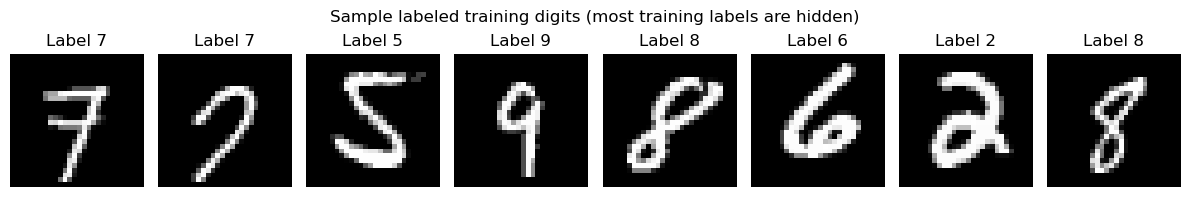

In [3]:
# Visualize a few labeled training digits
n_show = 8

fig, axes = plt.subplots(1, n_show, figsize=(12, 2))

side = int(np.sqrt(X_train.shape[1]))

show_idx = labeled_idx[:n_show]

for ax, i in zip(axes, show_idx):

    ax.imshow(X_train[i].reshape(side, side), cmap="gray")

    ax.set_title(f"Label {y_train[i]}")

    ax.axis("off")

plt.suptitle("Sample labeled training digits (most training labels are hidden)")

plt.tight_layout()

plt.show()


---

## 3. Supervised Baseline — Labeled Data Only

Train **Logistic Regression** on scaled pixels using **only** the labeled subset. This is the ceiling we beat when labels are scarce.


In [4]:
# Fit Logistic Regression (linear supervised classifier) on labeled pixels only
supervised_clf = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

supervised_clf.fit(X_train_scaled[labeled_mask], y_train[labeled_mask])

# Predict on held-out test set — true labels used for evaluation only
y_pred_supervised = supervised_clf.predict(X_test_scaled)

acc_supervised = accuracy_score(y_test, y_pred_supervised)

print(f"Supervised-only (LogisticRegression, {LABELED_FRACTION:.1%} labels): test accuracy = {acc_supervised:.2%}")


Supervised-only (LogisticRegression, 7.5% labels): test accuracy = 81.58%


In [5]:
# Optional: small MLP (Multi-Layer Perceptron) on the same labeled subset for comparison
mlp_clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=RANDOM_STATE)

mlp_clf.fit(X_train_scaled[labeled_mask], y_train[labeled_mask])

acc_mlp = accuracy_score(y_test, mlp_clf.predict(X_test_scaled))

print(f"Supervised-only (MLP, {LABELED_FRACTION:.1%} labels): test accuracy = {acc_mlp:.2%}")


Supervised-only (MLP, 7.5% labels): test accuracy = 81.42%


---

## 4. Unsupervised Step — PCA + k-Means

Fit **PCA** and **k-Means** on **all** training pixels (labeled and unlabeled). Labels are **not** passed to these algorithms.

We then map each cluster to a digit using **only labeled points inside that cluster** — this mapping is used later for pseudo-labels.


In [6]:
# Number of PCA (Principal Component Analysis) components — enough for digit structure, fast to compute
N_PCA = 30

# Fit PCA on all training data (unsupervised — no labels)
pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

# Fit k-Means with k=10 (one cluster per digit class)
kmeans = KMeans(n_clusters=10, n_init=10, max_iter=300, random_state=RANDOM_STATE)

train_clusters = kmeans.fit_predict(X_train_pca)

test_clusters = kmeans.predict(X_test_pca)

print(f"PCA reduced {X_train.shape[1]} dims → {N_PCA} dims")

print(f"Variance retained: {pca.explained_variance_ratio_.sum():.1%}")

print(f"k-Means inertia (WCSS): {kmeans.inertia_:.2f}")


PCA reduced 784 dims → 30 dims
Variance retained: 50.4%
k-Means inertia (WCSS): 1035696.35


In [7]:
# Map each cluster to the most common digit among LABELED points in that cluster
cluster_to_digit = {}

cluster_purity = {}

for c in range(10):

    mask = (train_clusters == c) & labeled_mask

    if mask.sum() == 0:

        cluster_to_digit[c] = c  # fallback if no labeled point in cluster

        cluster_purity[c] = 0.0

        continue

    counts = pd.Series(y_train[mask]).value_counts()

    cluster_to_digit[c] = int(counts.index[0])

    cluster_purity[c] = counts.iloc[0] / counts.sum()

cluster_map_df = pd.DataFrame({
    "cluster": list(cluster_to_digit.keys()),
    "assigned_digit": list(cluster_to_digit.values()),
    "purity_from_labeled": list(cluster_purity.values()),
})

print("Cluster → digit mapping (derived from labeled subset only):")

display(cluster_map_df)


Cluster → digit mapping (derived from labeled subset only):


,cluster,assigned_digit,purity_from_labeled
0,0,3,0.571429
1,1,4,0.403509
2,2,0,0.454545
3,3,0,0.947368
4,4,7,0.642857
5,5,2,0.600000
6,6,1,0.528302
7,7,6,0.775510
8,8,8,0.324324
9,9,7,0.475000


In [8]:
# Unsupervised-only classifier: assign test points the digit mapped from their cluster
y_pred_unsup = np.array([cluster_to_digit[c] for c in test_clusters])

acc_unsupervised = accuracy_score(y_test, y_pred_unsup)

print(f"Unsupervised-only (PCA + k-Means cluster mapping): test accuracy = {acc_unsupervised:.2%}")

print("(Clusters never saw test labels — mapping uses labeled train points only.)")


Unsupervised-only (PCA + k-Means cluster mapping): test accuracy = 51.33%
(Clusters never saw test labels — mapping uses labeled train points only.)


---

## 5. Semisupervised Model — Pseudo-Labels + Enriched Features

**Steps (book-style semisupervised workflow):**

1. Build **enriched features** = scaled pixels **concatenated with** PCA components (PCA fit on **all** data — unsupervised)
2. Train an initial classifier on **labeled** enriched features
3. Assign **pseudo-labels** to unlabeled rows where the initial model is **confident** (self-training)
4. Retrain on **labeled + confident pseudo-labeled** data

Low-confidence unlabeled points are **skipped** — quality over quantity.


In [9]:
# Concatenate raw scaled pixels with PCA features (supervised + unsupervised information)
X_train_enriched = np.hstack([X_train_scaled, X_train_pca])

X_test_enriched = np.hstack([X_test_scaled, X_test_pca])

# Supervised on enriched features (labeled only) — shows value of unsupervised PCA alone
enriched_clf = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

enriched_clf.fit(X_train_enriched[labeled_mask], y_train[labeled_mask])

acc_enriched = accuracy_score(y_test, enriched_clf.predict(X_test_enriched))

print(f"Supervised + enriched features (labeled only): test accuracy = {acc_enriched:.2%}")

# Self-training: initial model assigns pseudo-labels to confident unlabeled points
init_clf = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

init_clf.fit(X_train_enriched[labeled_mask], y_train[labeled_mask])

unlabeled_proba = init_clf.predict_proba(X_train_enriched[unlabeled_mask])

confidence = unlabeled_proba.max(axis=1)

pseudo_pred = init_clf.classes_[unlabeled_proba.argmax(axis=1)]

pseudo_labels = np.full(len(y_train), -1, dtype=int)

pseudo_mask = np.zeros(len(y_train), dtype=bool)

for idx, conf, pred in zip(np.where(unlabeled_mask)[0], confidence, pseudo_pred):

    if conf >= PSEUDO_LABEL_CONFIDENCE:

        pseudo_labels[idx] = pred

        pseudo_mask[idx] = True

n_pseudo = pseudo_mask.sum()

semi_mask = labeled_mask | pseudo_mask

y_semi_train = np.where(labeled_mask, y_train, pseudo_labels)

print(f"Pseudo-labeled training points: {n_pseudo} (model confidence ≥ {PSEUDO_LABEL_CONFIDENCE:.0%})")

print(f"Total semisupervised training points: {semi_mask.sum()} (labeled + pseudo)")


Supervised + enriched features (labeled only): test accuracy = 82.00%


Pseudo-labeled training points: 3658 (model confidence ≥ 75%)
Total semisupervised training points: 4018 (labeled + pseudo)


In [10]:
# Train semisupervised classifier on enriched features
semi_clf = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

semi_clf.fit(X_train_enriched[semi_mask], y_semi_train[semi_mask])

y_pred_semi = semi_clf.predict(X_test_enriched)

acc_semisupervised = accuracy_score(y_test, y_pred_semi)

print(f"Semisupervised (self-training + enriched features): test accuracy = {acc_semisupervised:.2%}")


Semisupervised (self-training + enriched features): test accuracy = 82.67%


---

## 6. Compare All Approaches

The **semisupervised** pipeline often beats **supervised-only** when labels are scarce — because unlabeled data shaped PCA/k-Means, and pseudo-labels expand training set size.


Label budget: 7.5% of training data  |  Evaluation: held-out test set


,Approach,Test accuracy
0,"Supervised only (LogisticRegression, raw pixels)",81.58%
1,Supervised only (MLP),81.42%
2,Supervised + PCA features (labeled only),82.00%
3,Unsupervised only (PCA + k-Means),51.33%
4,Semisupervised (self-training + enriched featu...,82.67%


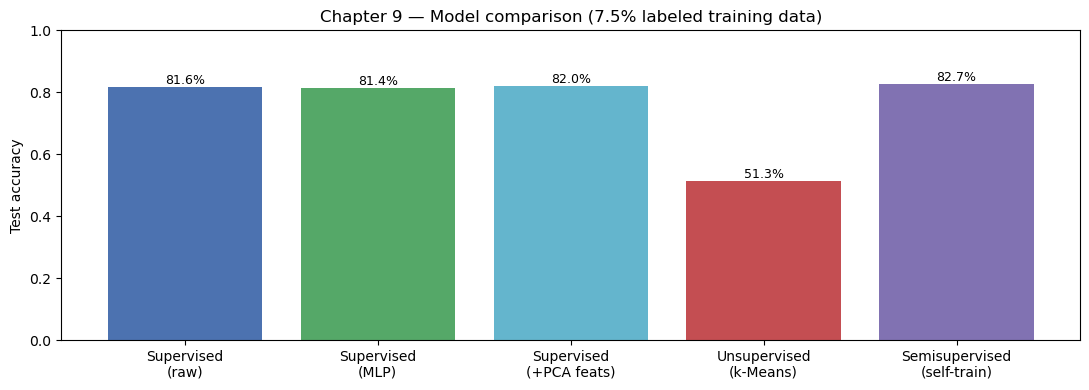

In [11]:
# Build comparison table and bar chart
results = pd.DataFrame([
    {"Approach": "Supervised only (LogisticRegression, raw pixels)", "Test accuracy": acc_supervised},
    {"Approach": "Supervised only (MLP)", "Test accuracy": acc_mlp},
    {"Approach": "Supervised + PCA features (labeled only)", "Test accuracy": acc_enriched},
    {"Approach": "Unsupervised only (PCA + k-Means)", "Test accuracy": acc_unsupervised},
    {"Approach": "Semisupervised (self-training + enriched features)", "Test accuracy": acc_semisupervised},
])

results["Test accuracy"] = results["Test accuracy"].map(lambda x: f"{x:.2%}")

print(f"Label budget: {LABELED_FRACTION:.1%} of training data  |  Evaluation: held-out test set")

display(results)

acc_values = [acc_supervised, acc_mlp, acc_enriched, acc_unsupervised, acc_semisupervised]

labels = ["Supervised\n(raw)", "Supervised\n(MLP)", "Supervised\n(+PCA feats)", "Unsupervised\n(k-Means)", "Semisupervised\n(self-train)"]

plt.figure(figsize=(11, 4))

bars = plt.bar(labels, acc_values, color=["#4C72B0", "#55A868", "#64B5CD", "#C44E52", "#8172B2"])

plt.ylabel("Test accuracy")

plt.title(f"Chapter 9 — Model comparison ({LABELED_FRACTION:.1%} labeled training data)")

plt.ylim(0, 1)

for bar, val in zip(bars, acc_values):

    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.1%}", ha="center", fontsize=9)

plt.tight_layout()

plt.show()


---

## 7. The Power of Combining Supervised and Unsupervised Learning

| Source of information | What it provides |
|-----------------------|------------------|
| **Few labels** | Correct class names for some points — anchors decision boundaries |
| **Many unlabeled points** | Shape of digit manifolds via PCA and cluster structure |
| **Pseudo-labels** | Spread label signal to similar unlabeled neighbors |
| **Feature fusion (raw + PCA)** | Classifier sees both pixel detail and compressed structure |

**When semisupervised helps most:** labels are expensive, classes are separable in unsupervised geometry, and pseudo-labels are **confident** (high cluster purity).

**When it fails:** clusters do not align with classes, or wrong pseudo-labels **amplify** errors.


---

## 8. Glossary — All Chapter 9 Terms

| Term | One-line definition |
|------|---------------------|
| **Semisupervised learning** | Train with few labels plus many unlabeled examples |
| **Labeled subset** | Training points whose class is known to the algorithm |
| **Unlabeled subset** | Training points with hidden labels during training |
| **Pseudo-label** | Class assigned to an unlabeled point from a model or cluster |
| **PCA (Principal Component Analysis)** | Linear compression of pixel features |
| **k-Means** | Partition data into k clusters around centroids |
| **Cluster purity** | Fraction of labeled points in a cluster sharing the majority digit |
| **Feature enrichment** | Concatenate supervised (raw) and unsupervised (PCA) features |
| **Logistic Regression** | Linear classifier for multi-class digits |
| **MLP (Multi-Layer Perceptron)** | Small neural network classifier |
| **Held-out test set** | Data never used for training — labels for evaluation only |
| **Label leakage** | Accidentally using test information during training — avoid! |


---

## 9. Chapter 9 Summary

```
Semisupervised learning (Chapter 9) — MNIST digits
├── Split train / test; hide most train labels (≈7.5% labeled)
├── Supervised baseline → LogisticRegression / MLP on labeled only
├── Unsupervised → PCA + k-Means on ALL train pixels
│   └── Map clusters → digits using labeled points only
├── Semisupervised → pseudo-labels + [pixels | PCA] features
└── Compare test accuracy — unsupervised structure + few labels

True labels on test set: evaluation only
```

### What's next?

**Chapter 10** applies deep unsupervised models — **Restricted Boltzmann Machines (RBMs)** — to **recommender systems** and the MovieLens-style rating matrix.

---

### Practice questions

1. Why do we fit PCA on **all** training data instead of labeled data only?
2. What happens if pseudo-label confidence threshold is set to 0%?
3. When would semisupervised learning **hurt** performance vs supervised-only?
4. Why concatenate raw pixels **and** PCA features instead of using PCA alone?
5. How is semisupervised learning different from **self-training** with a supervised model alone?
